# Monte Carlo Basic Munich Radiomap

This notebook runs the standalone `witwin.channel.montecarlo` basic integrator on the Munich scene. It is configured as a raw first-order diffraction comparison against Sionna RT by default: `integrator="basic"`, `max_diffraction_order=1`, no shadow-boundary smoothing, and no power filtering.


In [1]:
from dataclasses import asdict
from pathlib import Path
import importlib
import sys
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith("witwin."):
        sys.modules.pop(module_name, None)

from witwin.channel.core.scene import ReceiverGrid, Scene, SionnaAdaptor, Transmitter
from witwin.channel.core.scene.edge_policy import EdgePolicy
from witwin.channel.core.grid import Grid
from witwin.channel.montecarlo import Config, FilterConfig, IntegratorOptions, NativeExtension, Tuning, solve

display({
    "repo_root": repo_root_str,
    "native_extension_available": NativeExtension.native_extension_available(),
})

jitc_llvm_init(): LLVM API initialization failed ..


{'repo_root': 'E:\\Code\\witwin-platform\\channel',
 'native_extension_available': True}

## Scene and Basic Configuration

Keep the default run raw when comparing against Sionna. Raise the Witwin diffraction, Witwin reflection-discovery, and Sionna sample budgets together after the raw maps look structurally aligned. The default Sionna edge-diffraction flag is disabled to match Witwin's default boundary-edge exclusion policy.


In [2]:
MUNICH_XML = repo_root / "reference" / "sionna-rt-reference-2.0.1" / "src" / "sionna" / "rt" / "scenes" / "munich" / "munich.xml"
FREQUENCY_HZ = 3.5e9
TX_POS = (8.5, 21.0, 27.0)
PLANE_Z = 1.5
BOUNDS = ((-120.0, 120.0), (-120.0, 140.0))
GRID_SHAPE = (256, 256)
DIFFRACTION_SAMPLE_BUDGET = 1_000_000
REFLECTION_RAY_BUDGET = 1_000_000
SIONNA_SAMPLE_BUDGET = 1_000_000
SIONNA_MAX_DEPTH = 1
SCENE_DEVICE = "cuda"
WITWIN_EDGE_SELECTION_MODE = "all_edges"
WITWIN_EDGE_DIFFRACTION = True
WITWIN_BOUNDARY_EDGE_POLICY = "half_plane"
SIONNA_EDGE_DIFFRACTION = True
SIONNA_DIFFRACTION_LIT_REGION = True
RAW_SHADOW_BOUNDARY_MODE = "none"
VISUAL_FILTERING = FilterConfig(
    reflection={"method": "gaussian", "radius": 1, "sigma": 0.9, "blend": 0.75},
    diffraction={"method": "bilateral", "radius": 2, "sigma": 1.25, "range_sigma": 2.0e-5, "blend": 1.0},
)

if not MUNICH_XML.exists():
    raise FileNotFoundError(f"Munich XML not found: {MUNICH_XML}")


def make_basic_config(
    *,
    diffraction_sample_budget,
    reflection_ray_budget,
    shadow_boundary_mode=RAW_SHADOW_BOUNDARY_MODE,
    filtering=None,
    ad=False,
):
    return Config(
        num_samples=int(reflection_ray_budget),
        max_bounces=int(SIONNA_MAX_DEPTH),
        max_diffraction_order=1,
        edge_policy=EdgePolicy(
            edge_selection_mode=WITWIN_EDGE_SELECTION_MODE,
            edge_diffraction=WITWIN_EDGE_DIFFRACTION,
            boundary_edge_policy=WITWIN_BOUNDARY_EDGE_POLICY,
        ),
        tuning=Tuning(
            enable_rd_diffraction=True,
            shadow_boundary_mode=str(shadow_boundary_mode),
            shadow_boundary_backend="auto",
            shadow_boundary_tile_shape=(8, 8),
            shadow_boundary_band_width_wavelengths=3.0,
            shadow_boundary_max_candidate_factor=128.0,
            diffraction_execution={"accumulate_primal": "rayd_optix"},
        ),
        integrator_options=IntegratorOptions(
            integrator="basic",
            samples_per_tx=int(diffraction_sample_budget),
            accumulation_backend="auto",
            seed=11,
            ad=bool(ad),
        ),
        filtering=filtering,
    )


scene = Scene.load_mitsuba(
    MUNICH_XML,
    device=SCENE_DEVICE,
    merge_shapes=True,
    frequency=FREQUENCY_HZ,
)
scene.add(Transmitter("tx", TX_POS))
grid = ReceiverGrid("rm", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=GRID_SHAPE)
scene.add(grid)
config = make_basic_config(
    diffraction_sample_budget=DIFFRACTION_SAMPLE_BUDGET,
    reflection_ray_budget=REFLECTION_RAY_BUDGET,
)

display({
    "scene_path": str(MUNICH_XML),
    "scene_device": scene.device,
    "structures": len(scene.structures),
    "triangles": None if scene.tri_data is None else int(scene.tri_data["n_triangles"]),
    "diffraction_edges": scene.n_diffraction_edges,
    "grid_shape": GRID_SHAPE,
    "bounds": BOUNDS,
    "tx_pos": TX_POS,
    "frequency_hz": FREQUENCY_HZ,
    "integrator": config.integrator_options.integrator,
    "max_diffraction_order": config.max_diffraction_order,
    "witwin_edge_selection_mode": WITWIN_EDGE_SELECTION_MODE,
    "witwin_edge_diffraction": config.edge_policy.edge_diffraction,
    "witwin_boundary_edge_policy": config.edge_policy.boundary_edge_policy,
    "sionna_edge_diffraction": SIONNA_EDGE_DIFFRACTION,
    "sionna_diffraction_lit_region": SIONNA_DIFFRACTION_LIT_REGION,
    "diffraction_sample_budget": DIFFRACTION_SAMPLE_BUDGET,
    "reflection_ray_budget": REFLECTION_RAY_BUDGET,
    "sionna_sample_budget": SIONNA_SAMPLE_BUDGET,
    "max_bounces": config.max_bounces,
    "sionna_max_depth": SIONNA_MAX_DEPTH,
    "shadow_boundary_mode": config.tuning.shadow_boundary_mode,
    "filtering": asdict(config.filtering) if config.filtering is not None else None,
    "mitsuba_metadata": scene.metadata.get("mitsuba"),
})


{'scene_path': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src\\sionna\\rt\\scenes\\munich\\munich.xml',
 'scene_device': 'cuda',
 'structures': 11,
 'triangles': 38936,
 'diffraction_edges': 51650,
 'grid_shape': (256, 256),
 'bounds': ((-120.0, 120.0), (-120.0, 140.0)),
 'tx_pos': (8.5, 21.0, 27.0),
 'frequency_hz': 3500000000.0,
 'integrator': 'basic',
 'max_diffraction_order': 1,
 'witwin_edge_selection_mode': 'all_edges',
 'witwin_edge_diffraction': True,
 'witwin_boundary_edge_policy': 'half_plane',
 'sionna_edge_diffraction': True,
 'sionna_diffraction_lit_region': True,
 'diffraction_sample_budget': 1000000,
 'reflection_ray_budget': 1000000,
 'sionna_sample_budget': 1000000,
 'max_bounces': 1,
 'sionna_max_depth': 1,
 'shadow_boundary_mode': 'none',
 'filtering': None,
 'mitsuba_metadata': {'source_path': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src\\sionna\\rt\\scenes\\munich\\munich.xml',
  'loader': 'sionna.rt

## TX Placement Check

In [3]:
def _scalar_value(value):
    array = np.asarray(value)
    return float(array.reshape(-1)[0])


def _point3_values(value):
    return [_scalar_value(value[index]) for index in range(3)]


def tx_placement_check():
    rt = SionnaAdaptor.load_rt(prefer_local=True)
    mi = importlib.import_module("mitsuba")
    tx_scene = rt.load_scene(str(MUNICH_XML), merge_shapes=False)
    bbox_hits = []
    for object_name, scene_object in tx_scene.objects.items():
        bbox = scene_object.mi_mesh.bbox()
        bbox_min = [float(value) for value in bbox.min]
        bbox_max = [float(value) for value in bbox.max]
        inside_bbox = (
            bbox_min[0] <= TX_POS[0] <= bbox_max[0]
            and bbox_min[1] <= TX_POS[1] <= bbox_max[1]
            and bbox_min[2] <= TX_POS[2] <= bbox_max[2]
        )
        if inside_bbox:
            bbox_hits.append({"object": str(object_name), "bbox_min": bbox_min, "bbox_max": bbox_max})

    ray_hits = {}
    for name, direction in {
        "+z": (0.0, 0.0, 1.0),
        "-z": (0.0, 0.0, -1.0),
        "+x": (1.0, 0.0, 0.0),
        "-x": (-1.0, 0.0, 0.0),
        "+y": (0.0, 1.0, 0.0),
        "-y": (0.0, -1.0, 0.0),
    }.items():
        ray = mi.Ray3f(mi.Point3f(*TX_POS), mi.Vector3f(*direction))
        si = tx_scene.mi_scene.ray_intersect(ray)
        valid = bool(np.asarray(si.is_valid()).reshape(-1)[0])
        ray_hits[name] = None if not valid else {
            "distance_m": _scalar_value(si.t),
            "point": _point3_values(si.p),
        }

    clearance_below = None if ray_hits["-z"] is None else ray_hits["-z"]["distance_m"]
    return {
        "tx_pos": tuple(float(value) for value in TX_POS),
        "bbox_containing_tx": bbox_hits,
        "ray_hits": ray_hits,
        "roof_clearance_below_m": clearance_below,
        "placement_interpretation": (
            "Open above and about 1 m above a building surface below; this is a rooftop transmitter placement, not a sealed-volume interior point."
            if ray_hits["+z"] is None and clearance_below is not None and clearance_below <= 2.0
            else "Review the ray hits before using this transmitter position."
        ),
    }


tx_placement = tx_placement_check()
display(tx_placement)


{'tx_pos': (8.5, 21.0, 27.0),
 'bbox_containing_tx': [{'object': 'Neues_Rathaus-itu_marble',
   'bbox_min': [-57.44551467895508, -108.90657043457031, 0.0],
   'bbox_max': [79.86839294433594, 56.970558166503906, 85.0]},
  {'object': 'Neues_Rathaus-itu_metal',
   'bbox_min': [-57.44551467895508, -108.90657043457031, 0.0],
   'bbox_max': [79.86839294433594, 56.970558166503906, 63.0]}],
 'ray_hits': {'+z': None,
  '-z': {'distance_m': 1.0, 'point': [8.500000953674316, 21.0, 26.0]},
  '+x': None,
  '-x': {'distance_m': 395.5854797363281,
   'point': [-387.08544921875, 21.0, 27.0]},
  '+y': None,
  '-y': {'distance_m': 184.3910675048828,
   'point': [8.5, -163.39108276367188, 27.0]}},
 'roof_clearance_below_m': 1.0,
 'placement_interpretation': 'Open above and about 1 m above a building surface below; this is a rooftop transmitter placement, not a sealed-volume interior point.'}

## Run Basic Monte Carlo

In [4]:
if not NativeExtension.native_extension_available():
    raise RuntimeError("The Monte Carlo native extension is required for this basic Munich example.")

start = time.perf_counter()
result = solve(
    scene=scene,
    transmitter="tx",
    receiver="rm",
    config=config,
)
solve_seconds = time.perf_counter() - start

path_gain = np.asarray(result.path_gain, dtype=np.float32)
components = {
    name: np.asarray(result.incoherent[name], dtype=np.float32)
    for name in ("los", "reflection", "diffraction", "raw_total", "total")
}
component_summary = {}
for name, values in components.items():
    db_values = 10.0 * np.log10(np.maximum(values, 1.0e-16))
    component_summary[name] = {
        "sum": float(np.sum(values, dtype=np.float64)),
        "max": float(np.max(values)),
        "nonzero_cells": int(np.count_nonzero(values > 0.0)),
        "cells_above_-90_db": int(np.count_nonzero(db_values > -90.0)),
        "cells_above_-120_db": int(np.count_nonzero(db_values > -120.0)),
    }

metadata = result.metadata
display({
    "solve_seconds": float(solve_seconds),
    "path_gain_shape": path_gain.shape,
    "path_gain_min": float(np.nanmin(path_gain)),
    "path_gain_max": float(np.nanmax(path_gain)),
    "component_summary": component_summary,
    "integrator": metadata.get("integrator"),
    "path_counts": metadata.get("path_counts"),
    "ray_sampling": metadata.get("ray_sampling"),
    "monte_carlo": metadata.get("monte_carlo"),
    "runtime_backends": metadata.get("runtime_backends"),
})


{'solve_seconds': 0.2124844000209123,
 'path_gain_shape': (1, 256, 256),
 'path_gain_min': 0.0,
 'path_gain_max': 5.564254388445988e-05,
 'component_summary': {'los': {'sum': 0.0001345754575379221,
   'max': 5.799830660180305e-08,
   'nonzero_cells': 13691,
   'cells_above_-90_db': 13691,
   'cells_above_-120_db': 13691},
  'reflection': {'sum': 4.2060504728424e-05,
   'max': 1.3560200962103863e-08,
   'nonzero_cells': 14087,
   'cells_above_-90_db': 12564,
   'cells_above_-120_db': 14087},
  'diffraction': {'sum': 9.178332994768092e-05,
   'max': 5.5604999943170696e-05,
   'nonzero_cells': 10097,
   'cells_above_-90_db': 341,
   'cells_above_-120_db': 7691},
  'raw_total': {'sum': 0.000268419291866286,
   'max': 5.564254388445988e-05,
   'nonzero_cells': 18800,
   'cells_above_-90_db': 14264,
   'cells_above_-120_db': 18136},
  'total': {'sum': 0.000268419291866286,
   'max': 5.564254388445988e-05,
   'nonzero_cells': 18800,
   'cells_above_-90_db': 14264,
   'cells_above_-120_db': 18

## Visualize Raw Path Gain

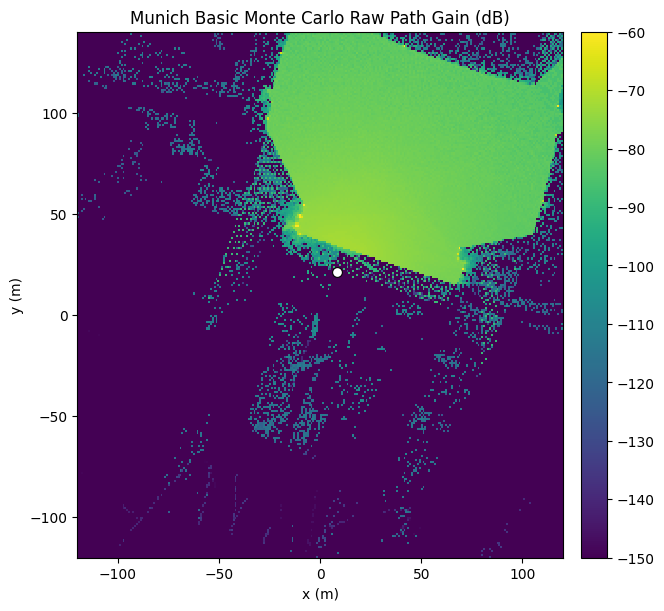

In [5]:
def path_gain_db(values, floor=1.0e-20):
    return 10.0 * np.log10(np.maximum(np.asarray(values, dtype=np.float64), float(floor)))


def map2d(values):
    array = np.asarray(values)
    if array.ndim == 3 and array.shape[0] == 1:
        return array[0]
    return array


def grid_extent(bounds):
    return (float(bounds[0][0]), float(bounds[0][1]), float(bounds[1][0]), float(bounds[1][1]))


fig, ax = plt.subplots(figsize=(7.0, 6.0), constrained_layout=True)
image = ax.imshow(
    path_gain_db(map2d(path_gain)),
    origin="lower",
    extent=grid_extent(BOUNDS),
    cmap="viridis",
    interpolation="nearest",
    vmin=-150.0,
    vmax=-60.0,
)
ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=50, edgecolors="black", linewidths=0.8)
ax.set_title("Munich Basic Monte Carlo Raw Path Gain (dB)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()


## Sionna RT First-Order Comparison

Sionna's radio-map solver is run with the same XML, transmitter position, frequency, grid, sample budget, and `max_depth=1`. The no-diffraction solve is used to isolate Sionna's positive diffraction increment. By default both sides enable edge diffraction: Witwin resolves `WITWIN_EDGE_DIFFRACTION=True` to its half-plane boundary-edge policy, and Sionna runs with `edge_diffraction=True`.


In [6]:
def sionna_radio_map_geometry(grid_spec):
    resolved = Grid.from_spec(grid_spec)
    return resolved, {
        "center": tuple(float(value) for value in resolved.center),
        "orientation": (0.0, 0.0, 0.0),
        "size": tuple(float(value) for value in resolved.size),
        "cell_size": tuple(float(value) for value in resolved.cell_size),
        "tensor_shape": tuple(int(value) for value in resolved.tensor_shape),
    }


def make_sionna_context():
    rt = SionnaAdaptor.load_rt(prefer_local=True)
    mi = importlib.import_module("mitsuba")
    sionna_scene = rt.load_scene(str(MUNICH_XML), merge_shapes=True)
    sionna_scene.frequency = FREQUENCY_HZ
    sionna_scene.tx_array = rt.PlanarArray(
        num_rows=1,
        num_cols=1,
        pattern="iso",
        polarization="V",
    )
    sionna_scene.add(rt.Transmitter("tx", position=mi.Point3f(*TX_POS), power_dbm=0.0))
    resolved_grid, geometry = sionna_radio_map_geometry(grid)
    solver_kwargs = {
        "center": mi.Point3f(*geometry["center"]),
        "orientation": mi.Point3f(*geometry["orientation"]),
        "size": mi.Point2f(*geometry["size"]),
        "cell_size": mi.Point2f(*geometry["cell_size"]),
        "samples_per_tx": int(SIONNA_SAMPLE_BUDGET),
        "max_depth": int(SIONNA_MAX_DEPTH),
        "los": True,
        "specular_reflection": True,
        "refraction": False,
        "diffraction_lit_region": bool(SIONNA_DIFFRACTION_LIT_REGION),
        "seed": int(config.integrator_options.seed),
    }
    return rt, mi, sionna_scene, rt.RadioMapSolver(), solver_kwargs, resolved_grid, geometry


def run_sionna_radio_map(solver, scene, solver_kwargs, *, diffraction):
    kwargs = dict(solver_kwargs)
    kwargs["diffraction"] = bool(diffraction)
    kwargs["edge_diffraction"] = bool(diffraction and SIONNA_EDGE_DIFFRACTION)
    start = time.perf_counter()
    radio_map = solver(scene, **kwargs)
    seconds = time.perf_counter() - start
    return {
        "radio_map": radio_map,
        "path_gain": np.asarray(radio_map.path_gain, dtype=np.float64)[0],
        "cell_centers": np.asarray(radio_map.cell_centers, dtype=np.float64),
        "seconds": float(seconds),
    }


rt, mi, sionna_scene, sionna_solver, sionna_kwargs, resolved_grid, sionna_geometry = make_sionna_context()
sionna_no_diff = run_sionna_radio_map(sionna_solver, sionna_scene, sionna_kwargs, diffraction=False)
sionna_with_diff = run_sionna_radio_map(sionna_solver, sionna_scene, sionna_kwargs, diffraction=True)

sionna_total = sionna_with_diff["path_gain"]
sionna_total_no_diff = sionna_no_diff["path_gain"]
sionna_diff_increment = sionna_total - sionna_total_no_diff
sionna_diff_positive = np.maximum(sionna_diff_increment, 0.0)
witwin_centers = np.stack(
    [
        np.asarray(resolved_grid.cell_centers.x, dtype=np.float64),
        np.asarray(resolved_grid.cell_centers.y, dtype=np.float64),
        np.asarray(resolved_grid.cell_centers.z, dtype=np.float64),
    ],
    axis=-1,
).reshape(resolved_grid.tensor_shape + (3,))
center_delta = witwin_centers - sionna_with_diff["cell_centers"]
max_center_delta = float(np.max(np.abs(center_delta)))
witwin_total = map2d(path_gain)
shape_match = tuple(int(value) for value in witwin_total.shape) == tuple(int(value) for value in sionna_total.shape)
if not shape_match:
    raise RuntimeError(f"Witwin/Sionna radio-map shape mismatch: {witwin_total.shape} vs {sionna_total.shape}")
if max_center_delta > 1.0e-4:
    raise RuntimeError(f"Witwin/Sionna cell centers differ by {max_center_delta:.6g} m")

witwin_db = path_gain_db(witwin_total)
sionna_db = path_gain_db(sionna_total)
delta_db = witwin_db - sionna_db
finite_delta = delta_db[np.isfinite(delta_db)]
comparison_summary = {
    "sionna_source": "sionna.rt.load_scene(..., merge_shapes=True)",
    "same_munich_xml": str(MUNICH_XML),
    "frequency_hz": float(FREQUENCY_HZ),
    "tx_pos": tuple(float(value) for value in TX_POS),
    "grid_center": sionna_geometry["center"],
    "grid_size": sionna_geometry["size"],
    "grid_cell_size": sionna_geometry["cell_size"],
    "witwin_tensor_shape": tuple(int(value) for value in witwin_total.shape),
    "sionna_tensor_shape": tuple(int(value) for value in sionna_total.shape),
    "max_cell_center_delta_m": max_center_delta,
    "witwin_samples_per_tx": int(config.integrator_options.samples_per_tx),
    "witwin_num_samples": int(config.num_samples),
    "sionna_samples_per_tx": int(SIONNA_SAMPLE_BUDGET),
    "sionna_max_depth": int(SIONNA_MAX_DEPTH),
    "sionna_edge_diffraction": bool(SIONNA_EDGE_DIFFRACTION),
    "sionna_diffraction_lit_region": bool(SIONNA_DIFFRACTION_LIT_REGION),
    "witwin_edge_selection_mode": str(WITWIN_EDGE_SELECTION_MODE),
    "witwin_edge_diffraction": bool(config.edge_policy.edge_diffraction),
    "witwin_boundary_edge_policy": str(config.edge_policy.boundary_edge_policy),
    "sionna_no_diff_seconds": sionna_no_diff["seconds"],
    "sionna_with_diff_seconds": sionna_with_diff["seconds"],
    "witwin_sum": float(np.sum(witwin_total, dtype=np.float64)),
    "sionna_sum": float(np.sum(sionna_total, dtype=np.float64)),
    "witwin_minus_sionna_db_p05_p50_p95": tuple(float(value) for value in np.percentile(finite_delta, [5.0, 50.0, 95.0])),
    "sionna_diff_increment_negative_cells": int(np.count_nonzero(sionna_diff_increment < 0.0)),
    "comparison_profile": "raw first-order basic Monte Carlo versus Sionna max_depth=1 with boundary-edge policy aligned",
}
display(comparison_summary)


{'sionna_source': 'sionna.rt.load_scene(..., merge_shapes=True)',
 'same_munich_xml': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src\\sionna\\rt\\scenes\\munich\\munich.xml',
 'frequency_hz': 3500000000.0,
 'tx_pos': (8.5, 21.0, 27.0),
 'grid_center': (0.0, 10.0, 1.5),
 'grid_size': (240.0, 260.0),
 'grid_cell_size': (0.9375, 1.015625),
 'witwin_tensor_shape': (256, 256),
 'sionna_tensor_shape': (256, 256),
 'max_cell_center_delta_m': 0.0,
 'witwin_samples_per_tx': 1000000,
 'witwin_num_samples': 1000000,
 'sionna_samples_per_tx': 1000000,
 'sionna_max_depth': 1,
 'sionna_edge_diffraction': True,
 'sionna_diffraction_lit_region': True,
 'witwin_edge_selection_mode': 'all_edges',
 'witwin_edge_diffraction': True,
 'witwin_boundary_edge_policy': 'half_plane',
 'sionna_no_diff_seconds': 0.027954499993938953,
 'sionna_with_diff_seconds': 0.31589769999845885,
 'witwin_sum': 0.000268419291866286,
 'sionna_sum': 0.00015829483248365746,
 'witwin_minus_sionna_db_

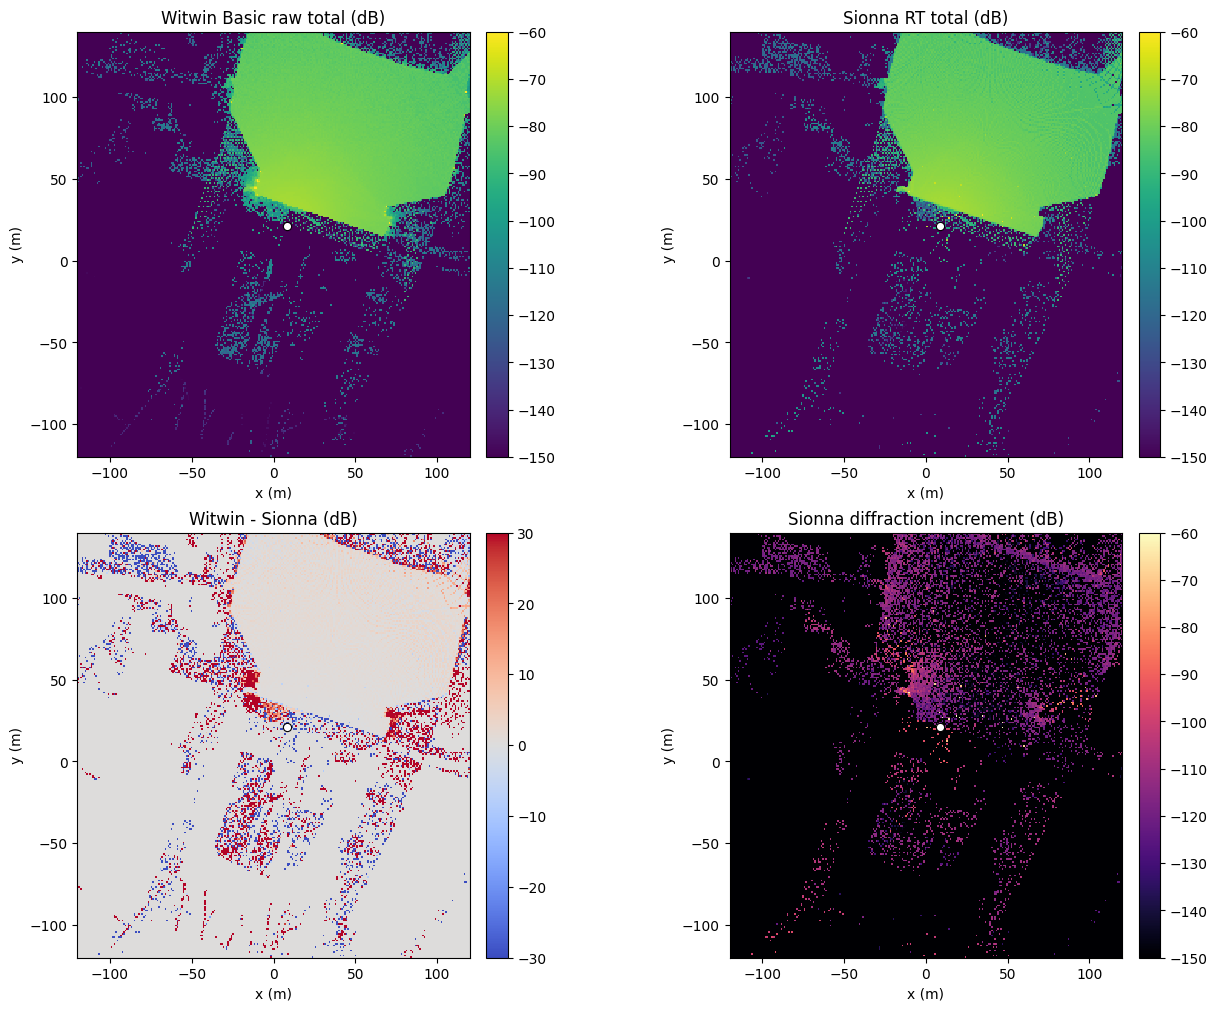

In [7]:
comparison_panels = (
    (path_gain_db(witwin_total), "Witwin Basic raw total (dB)", "viridis", -150.0, -60.0),
    (path_gain_db(sionna_total), "Sionna RT total (dB)", "viridis", -150.0, -60.0),
    (delta_db, "Witwin - Sionna (dB)", "coolwarm", -30.0, 30.0),
    (path_gain_db(sionna_diff_positive), "Sionna diffraction increment (dB)", "magma", -150.0, -60.0),
)
fig, axes = plt.subplots(2, 2, figsize=(13.0, 10.0), constrained_layout=True)
for ax, (values, title, cmap, vmin, vmax) in zip(np.asarray(axes).reshape(-1), comparison_panels, strict=True):
    image = ax.imshow(
        values,
        origin="lower",
        extent=grid_extent(BOUNDS),
        cmap=cmap,
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )
    ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()


## Component Maps

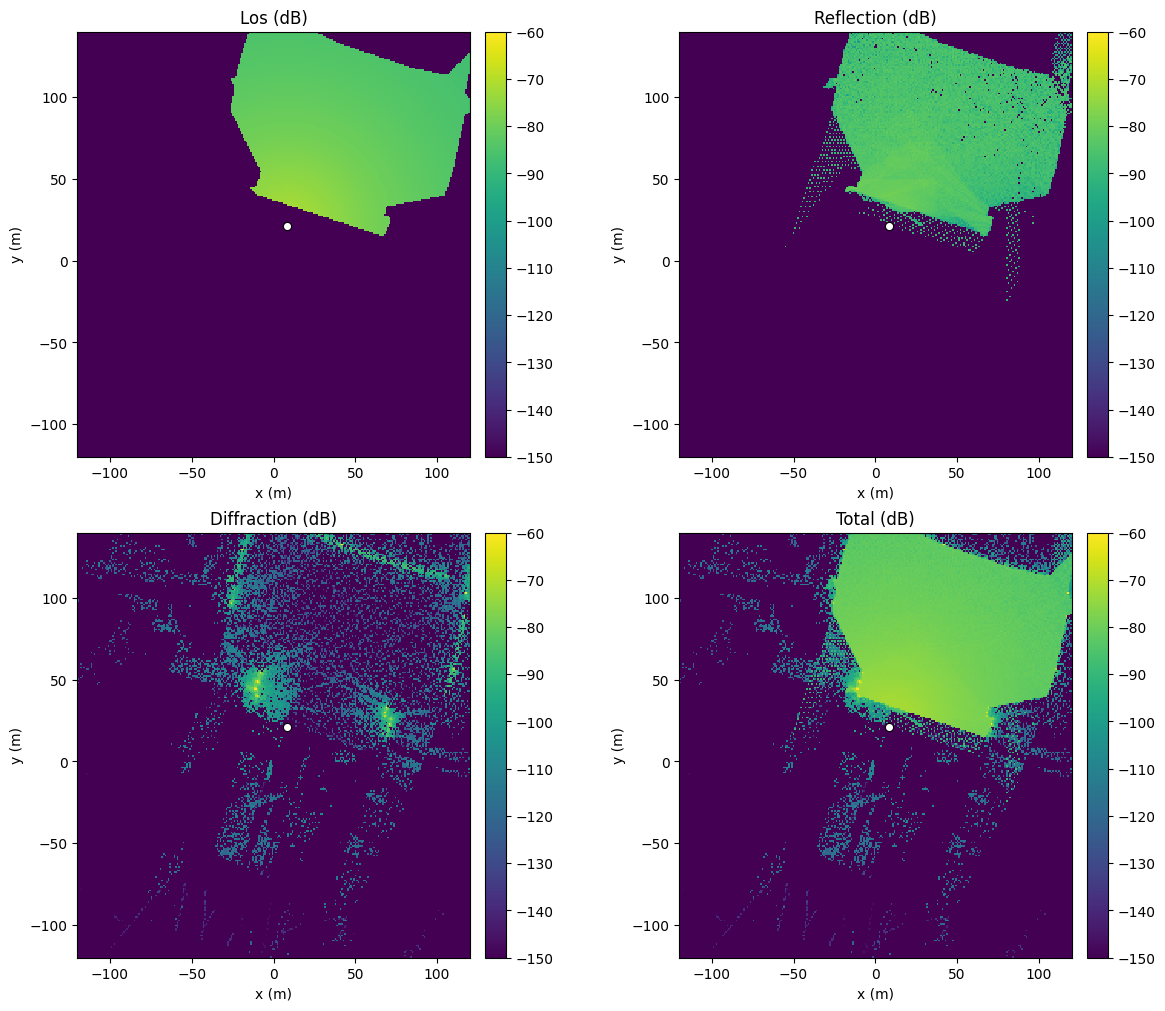

In [8]:
panel_names = ("los", "reflection", "diffraction", "total")
fig, axes = plt.subplots(2, 2, figsize=(12.0, 10.0), constrained_layout=True)
for ax, name in zip(np.asarray(axes).reshape(-1), panel_names, strict=True):
    image = ax.imshow(
        path_gain_db(map2d(components[name])),
        origin="lower",
        extent=grid_extent(BOUNDS),
        cmap="viridis",
        interpolation="nearest",
        vmin=-150.0,
        vmax=-60.0,
    )
    ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
    ax.set_title(f"{name.title()} (dB)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()


## Optional Smoothed Visual Run

Use this only after the raw comparison is understood. It enables UTD power smoothing and component filtering for visual inspection, so it is not a raw Sionna parity run.


In [9]:
RUN_VISUAL_SMOOTHING = False

if RUN_VISUAL_SMOOTHING:
    visual_config = make_basic_config(
        diffraction_sample_budget=DIFFRACTION_SAMPLE_BUDGET,
        reflection_ray_budget=REFLECTION_RAY_BUDGET,
        shadow_boundary_mode="utd_power_smoothing",
        filtering=VISUAL_FILTERING,
    )
    visual_start = time.perf_counter()
    visual_result = solve(
        scene=scene,
        transmitter="tx",
        receiver="rm",
        config=visual_config,
    )
    visual_seconds = time.perf_counter() - visual_start
    visual_path_gain = np.asarray(visual_result.path_gain, dtype=np.float32)

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.5), constrained_layout=True)
    for ax, values, title in (
        (axes[0], path_gain, "Raw basic total (dB)"),
        (axes[1], visual_path_gain, "Smoothed basic total (dB)"),
    ):
        image = ax.imshow(
            path_gain_db(map2d(values)),
            origin="lower",
            extent=grid_extent(BOUNDS),
            cmap="viridis",
            interpolation="nearest",
            vmin=-150.0,
            vmax=-60.0,
        )
        ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
        ax.set_title(title)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
    plt.show()
    display({
        "visual_seconds": float(visual_seconds),
        "visual_config": {
            "shadow_boundary_mode": visual_config.tuning.shadow_boundary_mode,
            "filtering": visual_asdict(config.filtering) if visual_config.filtering is not None else None,
        },
        "visual_monte_carlo": visual_result.metadata.get("monte_carlo"),
    })
else:
    display({
        "visual_smoothing_skipped": True,
        "set_RUN_VISUAL_SMOOTHING_to": True,
        "note": "Raw first-order comparison cells above are the default Sionna-parity path.",
    })


{'visual_smoothing_skipped': True,
 'set_RUN_VISUAL_SMOOTHING_to': True,
 'note': 'Raw first-order comparison cells above are the default Sionna-parity path.'}